# **Electron exibing Brownian Motion**

In this code we simulate ...

**Credits**
* Juan Andrés Guarín Rojas ([GitHub](https://github.com/AndresGuarin))


This notebook follows the next order
* [1. Computational scheme](#sec_1)

# **Import libraries**

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import ECond.simulation.solver as solver
import ECond.simulation.animation as ani

from datetime import datetime
from matplotlib import cm
from matplotlib.colors import Normalize

## **Some ideas**

* Only calculate forces for the moving particles (electrons)

## **1. Computational scheme** <a class="anchor" id="sec_1"></a>

We'll use the Langevin equation to model the Brownian motion
$$m \frac{d\vec{v}_i}{dt} = -m\gamma \vec{v}_i+\vec{R}+\vec{K}_i$$

The field force is given by the Coulombs' forces between the electrons, the lorentz force due to an external electromagnetic field, and the confinement potential
$$ \vec{K}_i = q_i\left(\vec{E} + \vec{v}_i\times\vec{B} \right) - q_i \vec{\nabla} \phi +  \sum\limits_{j=1}^{N}\frac{1}{4\pi\epsilon_0}\frac{q_i q_j}{r_{ij}^3}\vec{r}_{ij}\,,$$

For implementing this equations into the code we define the next dimensionless quantities:
$$\bar{t}=\sqrt{\frac{e^2}{4\pi\epsilon_0 m_e\sigma^3}}t\,, \,\,\,\,\,\,  \vec{r}' = \frac{\vec{r}}{\sigma}\,, \,\,\,\,\,\ \vec{v}' = \frac{d\vec{r}'}{d\bar{t}}\,, \,\,\,\,\,\ \bar{r}_{ij} =\frac{r_{ij}}{\sigma}\,, \,\,\,\,\,\ \bar{q}_i = \frac{q_i}{e}$$
where $\sigma=361.5\times 10^{-12}[\text{m}]$ is the lattice constant cristal structure of copper, $e$ is the elemental charge and $m_e$ is the electron rest mass. We also define the next dimensionless fields

$$\vec{E}' = \frac{4\pi\epsilon_0 \sigma^2}{e}\vec{E}\,, \,\,\,\,\,\, \vec{B}' = \sqrt{\frac{4\pi\epsilon_0\sigma^3}{m_e}} \vec{B}\,, \,\,\,\,\,\, \phi' = \frac{4\pi\epsilon_0 \sigma^3}{e} \phi$$

With this definitions the Newton's Law of motion for the electrons is left as

$$ \frac{d\vec{v}'_{i}}{d \bar{t}}= -\bar{\gamma}\vec{v}'_i + \vec{R}'+ \bar{q}_i \left(\vec{E}'+\vec{v}'_i\times\vec{B}' \right) -\bar{q}_i\frac{\partial \phi'}{\partial \vec{r}'}+\sum\limits_{j=1}^{N} \frac{\bar{q}_i \bar{q}_j}{\bar{r}_{ij}^2}\hat{r}'_{ij} \,. $$

## **2. Test**

In [2]:
def plot_intial_state(X0,Y0,Vx0,Vy0):
    plt.figure(figsize=(4,4))
    plt.plot(X0,Y0,'or')
    plt.quiver(X0, Y0, Vx0, Vy0, scale_units='xy',angles='xy',scale=3,color='orange',width=0.01)

    bb = np.max([np.abs(X0),np.abs(Y0)])*1.4
    plt.xlim(-bb,bb)
    plt.ylim(-bb,bb)

    plt.show()

In [ ]:
# Choose parameters 
h = 0.01; N = 500

# Set intial conditions
# electrons
X0 = np.array([-0.5,-0.5, 0.5, 0.5, 0.5])
Y0 = np.array([ 0.0, 1.0, 0.0,-1.0, 1.0])
Vx0 = np.array([-1, 0, 1, 1, 2])
Vy0 = np.array([ 1,-1, 0,-1, 0])

X0, Y0, Vx0, Vy0 = np.array([0.2]),np.array([0.2]),np.array([1]),np.array([1.2])

Np = len(X0)

# potential well
depth = 1
slope = 3
width = 3
def func(x):
    return np.tanh(slope*(x-width)) + np.tanh(slope*(-x-width))
def diff_func(x):
    return slope/np.cosh(slope*(x-width))**2 - slope/np.cosh(slope*(x+width))**2
def potential_Well(x,y):
    return func(x)*func(y)*depth
Q=-1

# Set external fields
def B0(X,Y,t):
    return X*0 #In order: [Bz]

def E0(X,Y,t):
     Ex = -depth*func(Y)*diff_func(X)
     Ey = -depth*func(X)*diff_func(Y)
     return [Ex, Ey] #In order: [Ex, Ey]

# Friction factor
gamma = 1

sim = solver.ECond(h,N,Np,E0,B0,gamma)
s = sim.simulate([X0,Y0,Vx0,Vy0])

self1 = sim.get_self()

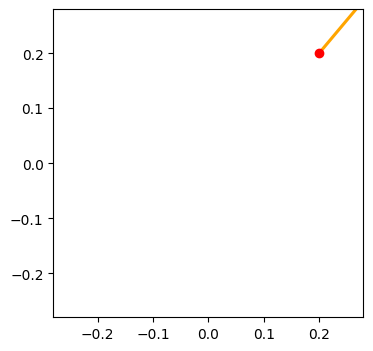

In [8]:
%matplotlib inline
plot_intial_state(X0,Y0,Vx0,Vy0)

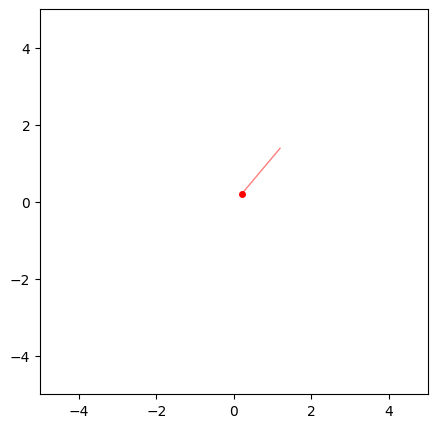

In [9]:
%matplotlib inline

plt.figure(figsize=(5,5))
for i in range(Np):
    X = s[0][:,i]
    Y = s[1][:,i]
    plt.plot(X,Y,'-r',lw=1,alpha=0.5)
    plt.plot(X[0],Y[0],'or',ms=4)
D=5
plt.xlim(-D,D)
plt.ylim(-D,D)
plt.show()

In [10]:
%matplotlib auto
%matplotlib auto

ani.animate_path(self1,s,save=False,verbose=True,j0=1,dj=4,interval=0,
                 plot_params=['-r','or',1, 6, 0.5], length=8,L=4)
#plt.show()

Using matplotlib backend: QtAgg
Using matplotlib backend: QtAgg


In [80]:
tt = np.linspace(-6,6,1000)
X,Y = np.meshgrid(tt,tt)
Z = Q*potential_Well(X,Y)

def func_g(x,y,depth=1,slope=3,width=3):
    fx=np.tanh(slope*(x-width)) + np.tanh(slope*(-x-width))
    fy=np.tanh(slope*(y-width)) + np.tanh(slope*(-y-width))
    return fx*fy*depth

Z2 = np.log(func_g(X,Y,slope=3))
norm = Normalize(vmin=Z2.min(), vmax=Z2.max())
colors=cm.bwr(norm(Z2))

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
surf = ax.plot_surface(X,Y,Z,facecolors=colors, edgecolor='none', antialiased=False)
mappable = cm.ScalarMappable(cmap='bwr')
mappable.set_array(Z2)

fig.colorbar(mappable, ax=ax, shrink=0.6, label='C values')
plt.show()